# **Librerias** 


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Funciones

In [65]:
%matplotlib inline

def EDA(data):
    # Definir variables para el análisis
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    categorical_cols = data.select_dtypes(include=['object']).columns

    print(f'Variables numéricas: {numeric_cols}')
    print(f'Variables categóricas: {categorical_cols}')

    # Crear figura con 3 columnas (Histograma, Boxplot, Violin) y 4 filas (una por cada variable)
    fig, axes = plt.subplots(len(numeric_cols), 3, figsize=(18, 5*len(numeric_cols)))
    fig.suptitle('ANÁLISIS EXPLORATORIO: Histograma, Boxplot y Violin Plot', 
                fontsize=16, fontweight='bold', y=0.995)

    for idx, col in enumerate(numeric_cols):
        # HISTOGRAMA
        axes[idx, 0].hist(data[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx, 0].set_title(f'Histograma: {col}', fontweight='bold')
        axes[idx, 0].set_xlabel('Valor')
        axes[idx, 0].set_ylabel('Frecuencia')
        axes[idx, 0].grid(axis='y', alpha=0.3)
        
        # BOXPLOT
        axes[idx, 1].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightblue', alpha=0.7),
                            medianprops=dict(color='red', linewidth=2))
        axes[idx, 1].set_title(f'Boxplot: {col}', fontweight='bold')
        axes[idx, 1].set_ylabel('Valor')
        axes[idx, 1].grid(axis='y', alpha=0.3)
        
        # VIOLIN PLOT
        parts = axes[idx, 2].violinplot(data[col].dropna(), vert=True, showmeans=True, showmedians=True)
        axes[idx, 2].set_title(f'Violin Plot: {col}', fontweight='bold')
        axes[idx, 2].set_ylabel('Valor')
        axes[idx, 2].grid(axis='y', alpha=0.3)

    plt.tight_layout()

    plt.show()

    

    print('='*80)
    print('ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS')
    print('='*80)
    print()
    print(data[numeric_cols].describe().to_string())

    print('\n' + '='*80)
    print('ANÁLISIS DETALLADO POR VARIABLE')
    print('='*80)

    for col in numeric_cols:
        print(f'\n📊 {col}')
        print(f'   Media: {data[col].mean():.4f}')
        print(f'   Mediana: {data[col].median():.4f}')
        print(f'   Desv. Estándar: {data[col].std():.4f}')
        print(f'   Mínimo: {data[col].min():.4f}')
        print(f'   Máximo: {data[col].max():.4f}')
        print(f'   Q1 (25%): {data[col].quantile(0.25):.4f}')
        print(f'   Q3 (75%): {data[col].quantile(0.75):.4f}')
        print(f'   IQR: {data[col].quantile(0.75) - data[col].quantile(0.25):.4f}')
        print(f'   Asimetría (Skewness): {stats.skew(data[col].dropna()):.4f}')
        print(f'   Curtosis (Kurtosis): {stats.kurtosis(data[col].dropna()):.4f}')

    # Calcular matriz de correlación
    correlation_matrix = data[numeric_cols].corr()

    print('='*80)
    print('MATRIZ DE CORRELACIÓN (PEARSON)')
    print('='*80)
    print(correlation_matrix.to_string())

    # Visualizar matriz de correlación
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={'shrink': 0.8}, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title('MATRIZ DE CORRELACIÓN DE PEARSON\nVariables Numéricas', 
                fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    
    plt.show()

    

    print('='*80)
    print('CORRELACIONES POR PARES - ANÁLISIS DETALLADO')
    print('='*80)

    correlations_list = []
    for i in range(len(numeric_cols)):
        for j in range(i+1, len(numeric_cols)):
            col1, col2 = numeric_cols[i], numeric_cols[j]
            
            # Pearson
            pearson_r, pearson_p = stats.pearsonr(data[col1].dropna(), data[col2].dropna())
            
            # Spearman
            spearman_r, spearman_p = stats.spearmanr(data[col1].dropna(), data[col2].dropna())
            
            correlations_list.append({
                'Variable 1': col1[:35],
                'Variable 2': col2[:35],
                'Pearson r': round(pearson_r, 4),
                'Pearson p-value': round(pearson_p, 6),
                'Spearman r': round(spearman_r, 4),
                'Spearman p-value': round(spearman_p, 6)
            })

    corr_results = pd.DataFrame(correlations_list).sort_values('Pearson p-value')
    print()
    print(corr_results.to_string(index=False))

    # Identificar correlaciones significativas
    print('\n' + '='*80)
    print('CORRELACIONES SIGNIFICATIVAS (p < 0.05)')
    print('='*80)
    significant = corr_results[corr_results['Pearson p-value'] < 0.05]
    if len(significant) > 0:
        print(significant.to_string(index=False))
    else:
        print('No se encontraron correlaciones significativas al nivel p < 0.05')

    # Crear scatter plots para todas las correlaciones
    n_pairs = len(correlations_list)
    n_cols = 2
    n_rows = (n_pairs + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle('SCATTER PLOTS - Correlaciones entre Variables Numéricas', 
                fontweight='bold', fontsize=14)

    for idx, row in enumerate(correlations_list):
        ax = axes[idx // n_cols, idx % n_cols]
        
        col1_name = row['Variable 1']
        col2_name = row['Variable 2']
        
        # Encontrar columnas originales completas
        col1 = [c for c in numeric_cols if col1_name in c][0]
        col2 = [c for c in numeric_cols if col2_name in c][0]
        
        # Scatter plot
        ax.scatter(data[col1], data[col2], alpha=0.6, s=50, color='steelblue', 
                edgecolor='black', linewidth=0.5)
        
        # Línea de tendencia
        z = np.polyfit(data[col1].dropna(), data[col2].dropna(), 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[col1].min(), data[col1].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8, label='Línea de tendencia')
        
        ax.set_xlabel(col1[:30], fontweight='bold')
        ax.set_ylabel(col2[:30], fontweight='bold')
        ax.set_title(f'r = {row["Pearson r"]:.3f} (p={row["Pearson p-value"]:.4f})', 
                    fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend()

    # Ocultar subplots vacíos
    for idx in range(n_pairs, n_rows*n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    plt.tight_layout()
    
    plt.show()

   

    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 5))
    fig.suptitle('DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS', fontweight='bold', fontsize=14)

    for idx, col in enumerate(categorical_cols):
        value_counts = data[col].value_counts()
        colors = sns.color_palette('husl', len(value_counts))
        
        axes[idx].barh(value_counts.index, value_counts.values, color=colors, 
                    alpha=0.8, edgecolor='black', linewidth=1.5)
        axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Frecuencia', fontweight='bold')
        
        # Agregar valores en las barras
        for i, v in enumerate(value_counts.values):
            axes[idx].text(v + 0.5, i, str(v), va='center', fontweight='bold')
        
        print(f'\n{col}:')
        print(value_counts.to_string())

    plt.tight_layout()
    
    plt.show()

    

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Variables Numéricas por Color Test de Predominancia', 
                fontweight='bold', fontsize=14)

    for idx, col in enumerate(numeric_cols):
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]
        
        sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax, 
                palette='Set2', linewidth=2)
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Color Test', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    plt.show()

    

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Variables Numéricas por Semestre-Grupo', 
                fontweight='bold', fontsize=14)

    for idx, col in enumerate(numeric_cols):
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]
        
        sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax, 
                    palette='muted')
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Semestre-Grupo', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    plt.show()
    plt.close('all')



# Datos

In [66]:
dataset_raw = pd.read_csv('Datos_Test_Semestres_analisis.csv')

## Tratamiento de faltantes

In [67]:
dataset_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   EQ.                                    536 non-null    int64  
 1   ID                                     536 non-null    object 
 2   Trabajo en Equipo 
(con factor) (50%)  536 non-null    float64
 3   Trabajo en Equipo 
(sin factor)        531 non-null    float64
 4   Co-evaluación                          536 non-null    float64
 5   Color Test de predominancia            509 non-null    object 
 6   CARRERA                                536 non-null    object 
 7   Etiqueta Semestre-Grupo                536 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 33.6+ KB


In [68]:
#Identificar Estudiantes con 0 en Trabajo en Equipo para eliminarlos del análisis
Est_0 = dataset_raw[dataset_raw['Trabajo en Equipo \n(con factor) (50%)'] == 0]
dataset_raw.drop(Est_0.index, inplace=True)

In [69]:
#Tratamiento de Nan en la columna de Test de Predominancia, asignando el tipo de test que menos se repite en el equipo al que pertenece el estudiante, o el que no se repite si es el caso.
test_values = dataset_raw['Color Test de predominancia'].dropna().unique().tolist()

test_Nan = dataset_raw[dataset_raw['Color Test de predominancia'].isna()]

teams_with_Nan = list(zip(test_Nan['ID'], test_Nan['EQ.'], test_Nan['Etiqueta Semestre-Grupo']))

for team in teams_with_Nan:
    team_data = dataset_raw[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2])]
    type_count = team_data['Color Test de predominancia'].value_counts()
    
    for i, type in enumerate(test_values):
        if type not in type_count.index: 
           dataset_raw.loc[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2]) & (dataset_raw['Color Test de predominancia'].isna()), 'Color Test de predominancia'] = type
           break
        if i == len(test_values) - 1: 
           dataset_raw.loc[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2]) & (dataset_raw['Color Test de predominancia'].isna()), 'Color Test de predominancia'] = type_count.idxmin()

In [70]:
for column in dataset_raw.columns:
    print(f"Columna '{column}' tiene {dataset_raw[column].isna().sum()} valores faltantes.")    

Columna 'EQ.' tiene 0 valores faltantes.
Columna 'ID' tiene 0 valores faltantes.
Columna 'Trabajo en Equipo 
(con factor) (50%)' tiene 0 valores faltantes.
Columna 'Trabajo en Equipo 
(sin factor)' tiene 0 valores faltantes.
Columna 'Co-evaluación' tiene 0 valores faltantes.
Columna 'Color Test de predominancia' tiene 0 valores faltantes.
Columna 'CARRERA' tiene 0 valores faltantes.
Columna 'Etiqueta Semestre-Grupo' tiene 0 valores faltantes.


## EDA (Individual)

Variables numéricas: Index(['EQ.', 'Trabajo en Equipo \n(con factor) (50%)',
       'Trabajo en Equipo \n(sin factor)', 'Co-evaluación'],
      dtype='object')
Variables categóricas: Index(['Color Test de predominancia', 'Etiqueta Semestre-Grupo'], dtype='object')


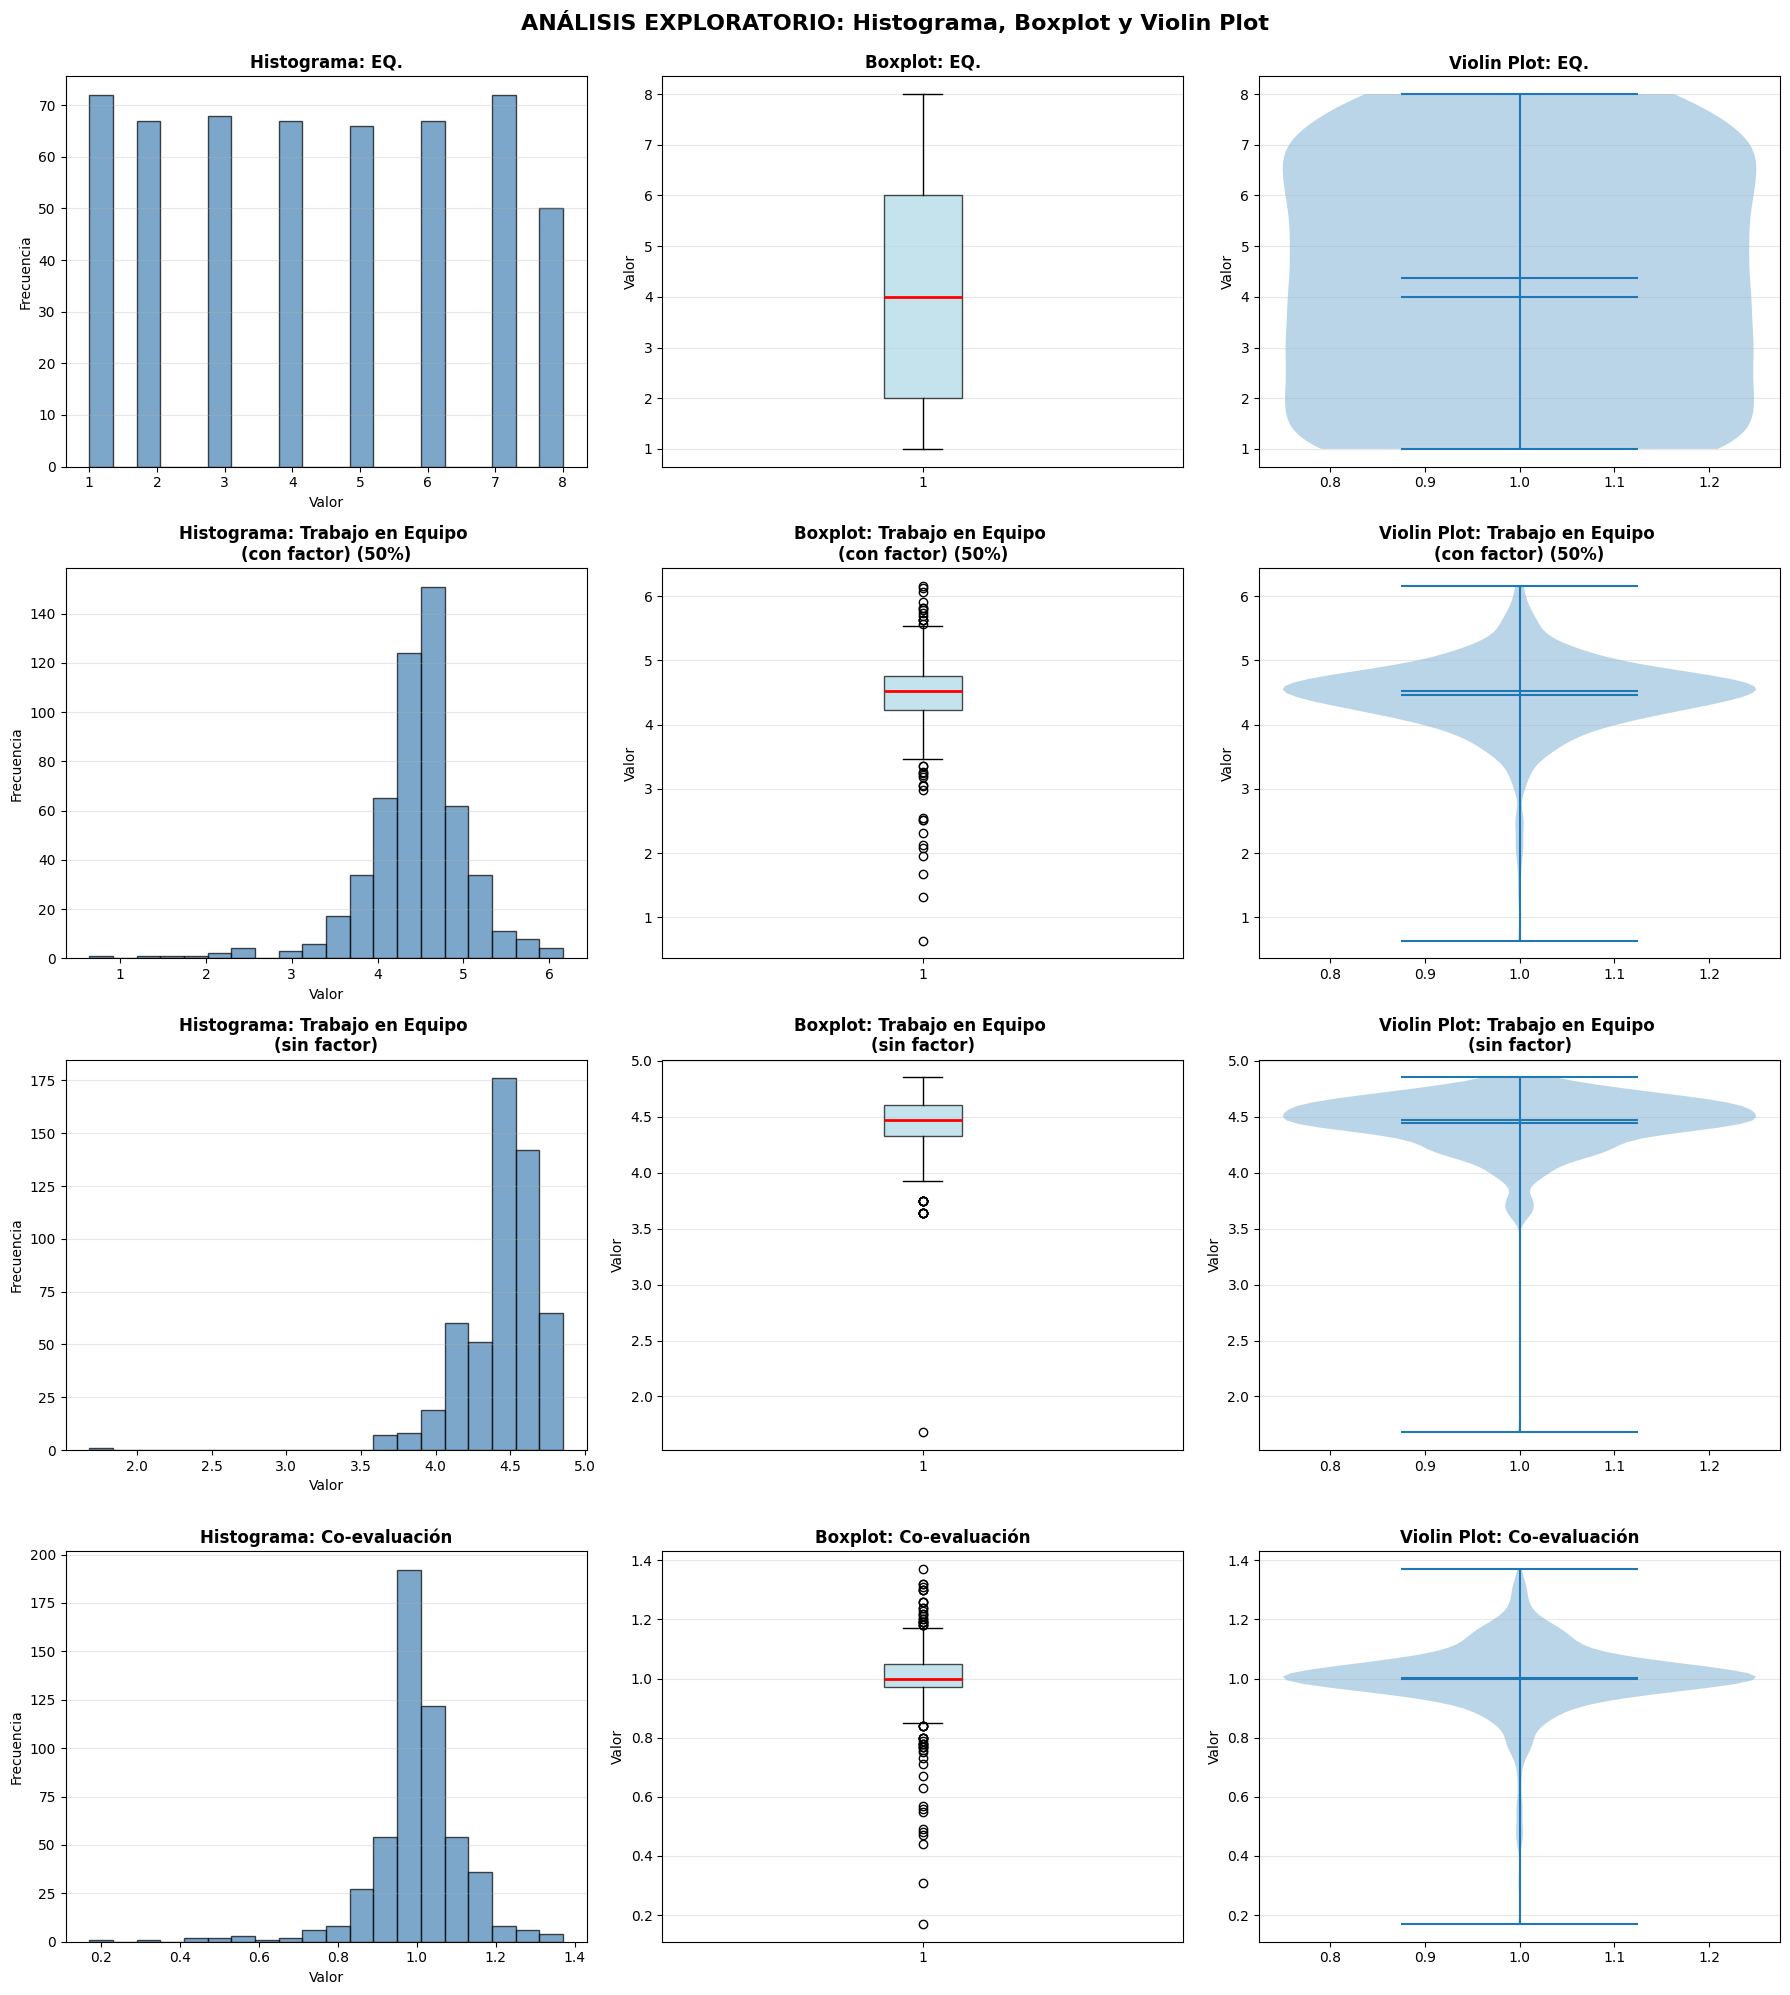

ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

              EQ.  Trabajo en Equipo \n(con factor) (50%)  Trabajo en Equipo \n(sin factor)  Co-evaluación
count  529.000000                              529.000000                        529.000000     529.000000
mean     4.374291                                4.459395                          4.444063       1.003310
std      2.257936                                0.593460                          0.262422       0.120387
min      1.000000                                0.640000                          1.680000       0.170000
25%      2.000000                                4.220000                          4.327915       0.970000
50%      4.000000                                4.520000                          4.475767       1.000000
75%      6.000000                                4.750000                          4.609235       1.050000
max      8.000000                                6.160000                          4.852667   

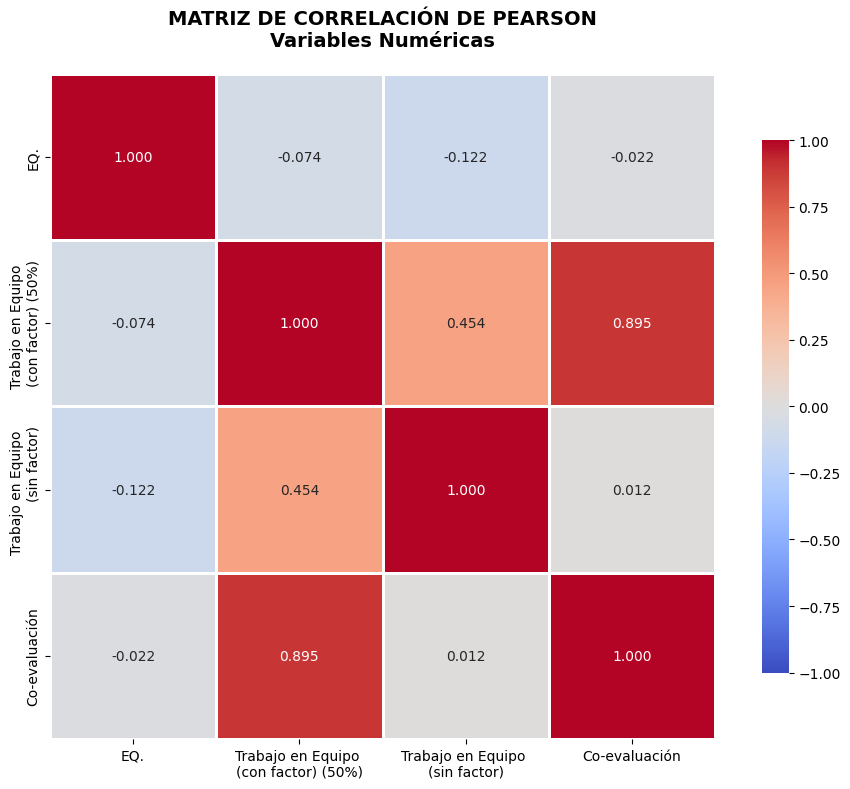

CORRELACIONES POR PARES - ANÁLISIS DETALLADO

                          Variable 1                           Variable 2  Pearson r  Pearson p-value  Spearman r  Spearman p-value
Trabajo en Equipo \n(con factor) (50     Trabajo en Equipo \n(sin factor)     0.4537         0.000000      0.4906          0.000000
Trabajo en Equipo \n(con factor) (50                        Co-evaluación     0.8949         0.000000      0.8068          0.000000
                                 EQ.     Trabajo en Equipo \n(sin factor)    -0.1223         0.004856     -0.1289          0.002969
                                 EQ. Trabajo en Equipo \n(con factor) (50    -0.0742         0.088074     -0.0744          0.087276
                                 EQ.                        Co-evaluación    -0.0217         0.618397     -0.0014          0.974040
    Trabajo en Equipo \n(sin factor)                        Co-evaluación     0.0123         0.777888     -0.0192          0.659975

CORRELACIONES SIGNIFICATIVAS 

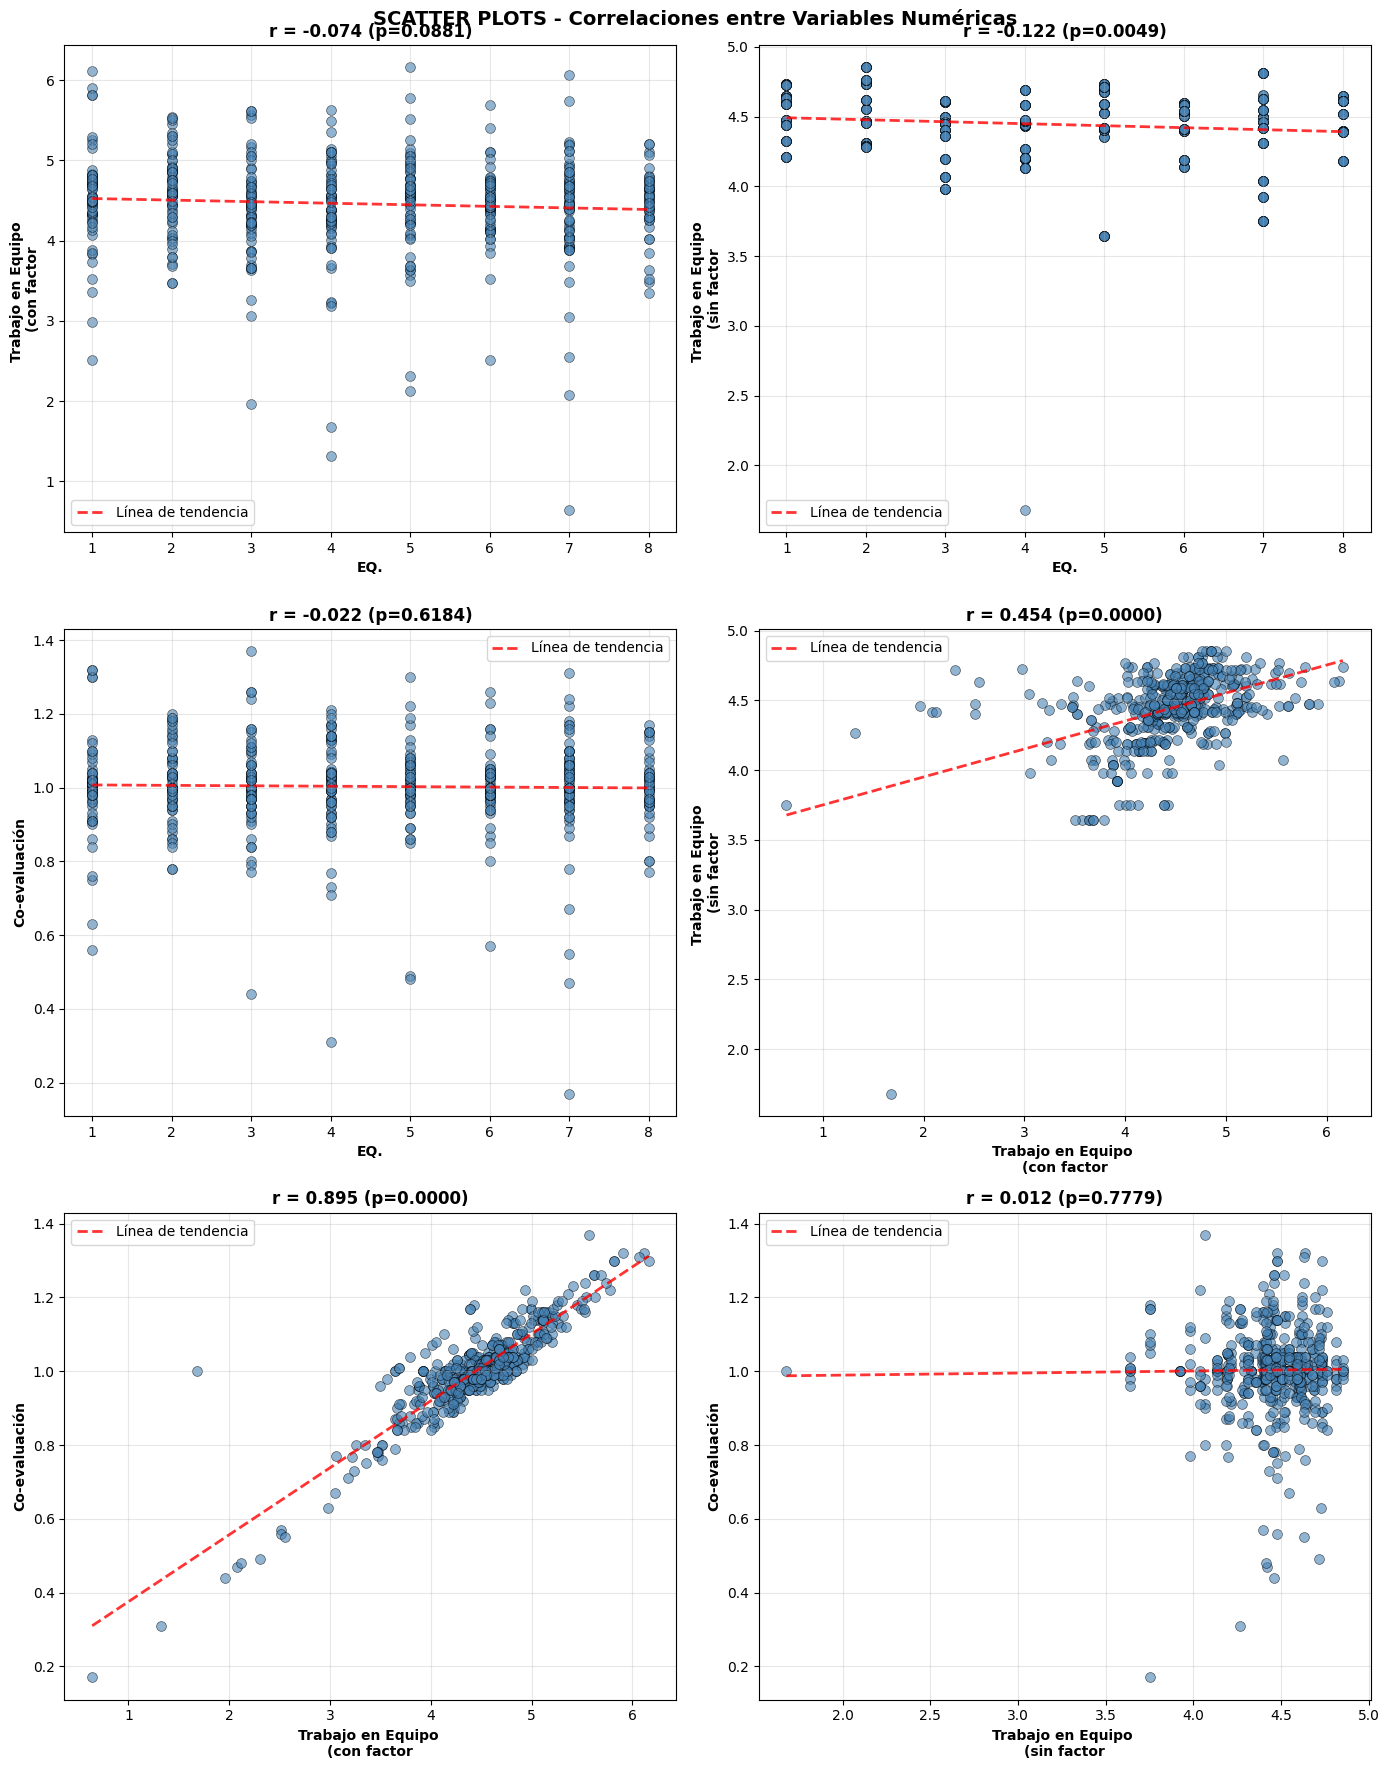


Color Test de predominancia:
Color Test de predominancia
Tipo A - Azul       251
Tipo B - Verde      143
Tipo C - Rojo        74
Tipo D - Naranja     61

Etiqueta Semestre-Grupo:
Etiqueta Semestre-Grupo
2023-02-G3       59
2023-01-G3       58
2024-02-G3       57
2024-01-G3       57
2022-02-G3       54
2021-01-G7       51
2021-02-G3-G7    49
2022-01-G3       49
2025-01-G3       49
2025-02-G3       46


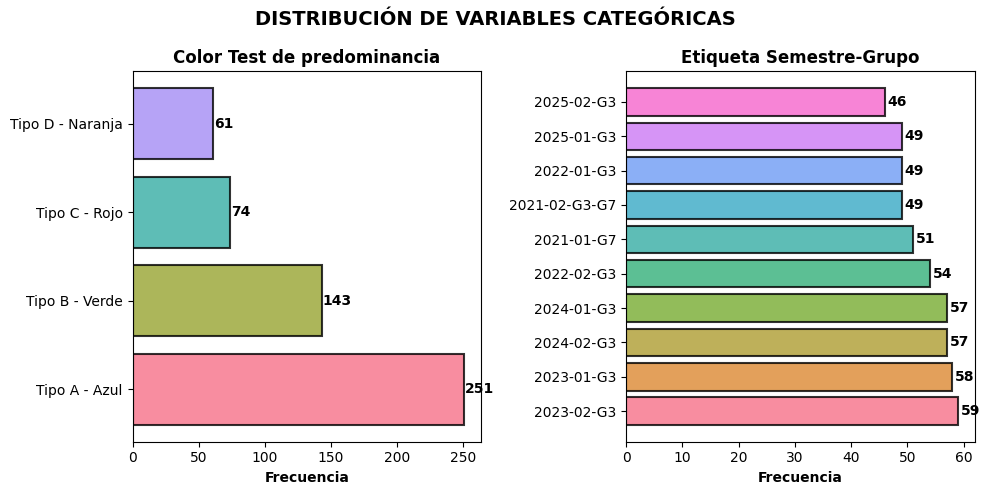

C:\Users\osqui\AppData\Local\Temp\ipykernel_13780\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_13780\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_13780\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local

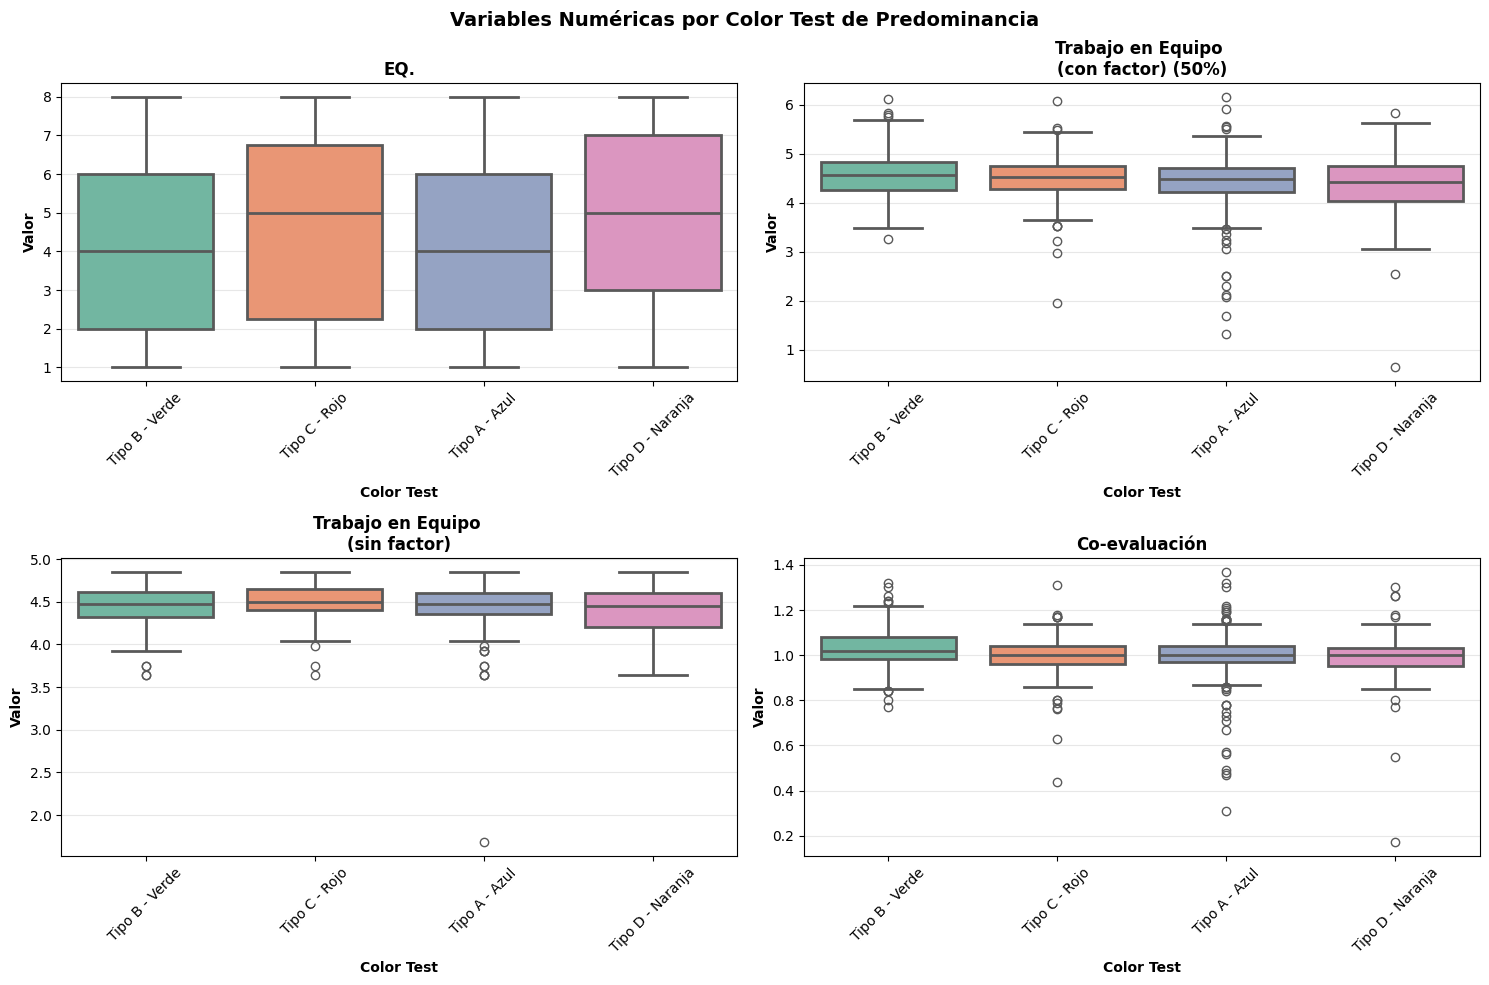

C:\Users\osqui\AppData\Local\Temp\ipykernel_13780\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_13780\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_13780\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Te

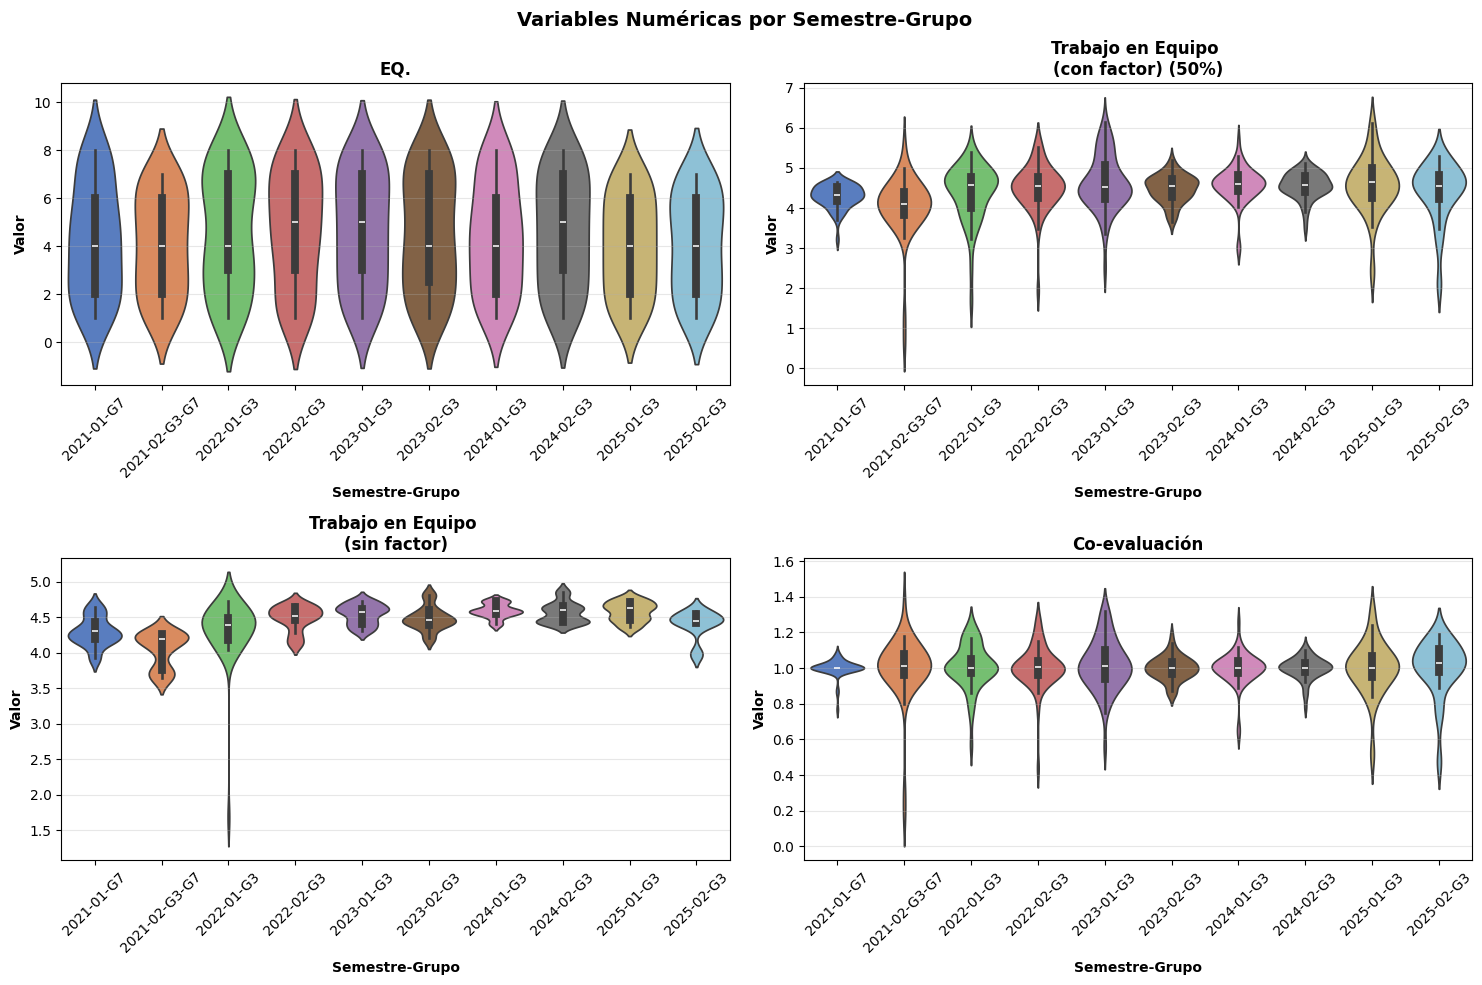

In [71]:
solo_data = dataset_raw.copy().drop(columns=['CARRERA']).set_index('ID')
EDA(solo_data)

# EDA (Grupal)

In [83]:
solo_data.columns.tolist()

['EQ.',
 'Trabajo en Equipo \n(con factor) (50%)',
 'Trabajo en Equipo \n(sin factor)',
 'Co-evaluación',
 'Color Test de predominancia',
 'Etiqueta Semestre-Grupo']

In [74]:
group_data.reset_index()

Color Test de predominancia,EQ.,Etiqueta Semestre-Grupo,Tipo A - Azul,Tipo B - Verde,Tipo C - Rojo,Tipo D - Naranja
0,1,2021-01-G7,4.0,1.0,1.0,1.0
1,1,2021-02-G3-G7,4.0,2.0,0.0,1.0
2,1,2022-01-G3,4.0,2.0,1.0,0.0
3,1,2022-02-G3,4.0,1.0,1.0,2.0
4,1,2023-01-G3,5.0,1.0,0.0,1.0
...,...,...,...,...,...,...
72,8,2022-02-G3,4.0,2.0,0.0,1.0
73,8,2023-01-G3,4.0,3.0,1.0,0.0
74,8,2023-02-G3,3.0,2.0,2.0,1.0
75,8,2024-01-G3,2.0,3.0,0.0,2.0


In [103]:
# Agrupación por equipo y etiqueta de semestre-grupo
# Esto calcula la cantidad de integrantes y suma el número de cada tipo de color,
# además del promedio de la nota de Trabajo en Equipo (sin factor).

grouped = solo_data.reset_index().groupby(['Etiqueta Semestre-Grupo', 'EQ.'])

integrantes = grouped.size().rename('Integrantes')
color_counts = grouped['Color Test de predominancia'].value_counts().unstack(fill_value=0)
team_score_mean = grouped['Trabajo en Equipo \n(sin factor)'].mean().rename('Promedio Trabajo en Equipo (sin factor)')

group_data = integrantes.to_frame().join(color_counts).join(team_score_mean)

group_data = pd.DataFrame(group_data[['Integrantes', 'Tipo A - Azul', 'Tipo B - Verde', 'Tipo C - Rojo', 'Tipo D - Naranja', 'Promedio Trabajo en Equipo (sin factor)']])
group_data.reset_index(inplace=True)
group_data.drop(columns=['Etiqueta Semestre-Grupo', 'EQ.', 'Integrantes'], inplace=True)
group_data

,Tipo A - Azul,Tipo B - Verde,Tipo C - Rojo,Tipo D - Naranja,Promedio Trabajo en Equipo (sin factor)
0,4,1,1,1,4.327915
1,2,3,1,2,4.309773
2,2,3,0,1,4.194719
3,3,1,2,1,4.198635
4,4,2,0,1,4.528585
...,...,...,...,...,...
72,1,4,1,1,3.980121
73,2,1,1,1,4.478219
74,2,2,1,2,4.417172
75,4,2,1,0,4.542977


Variables numéricas: Index(['Tipo A - Azul', 'Tipo B - Verde', 'Tipo C - Rojo', 'Tipo D - Naranja',
       'Promedio Trabajo en Equipo (sin factor)'],
      dtype='object')
Variables categóricas: Index([], dtype='object')


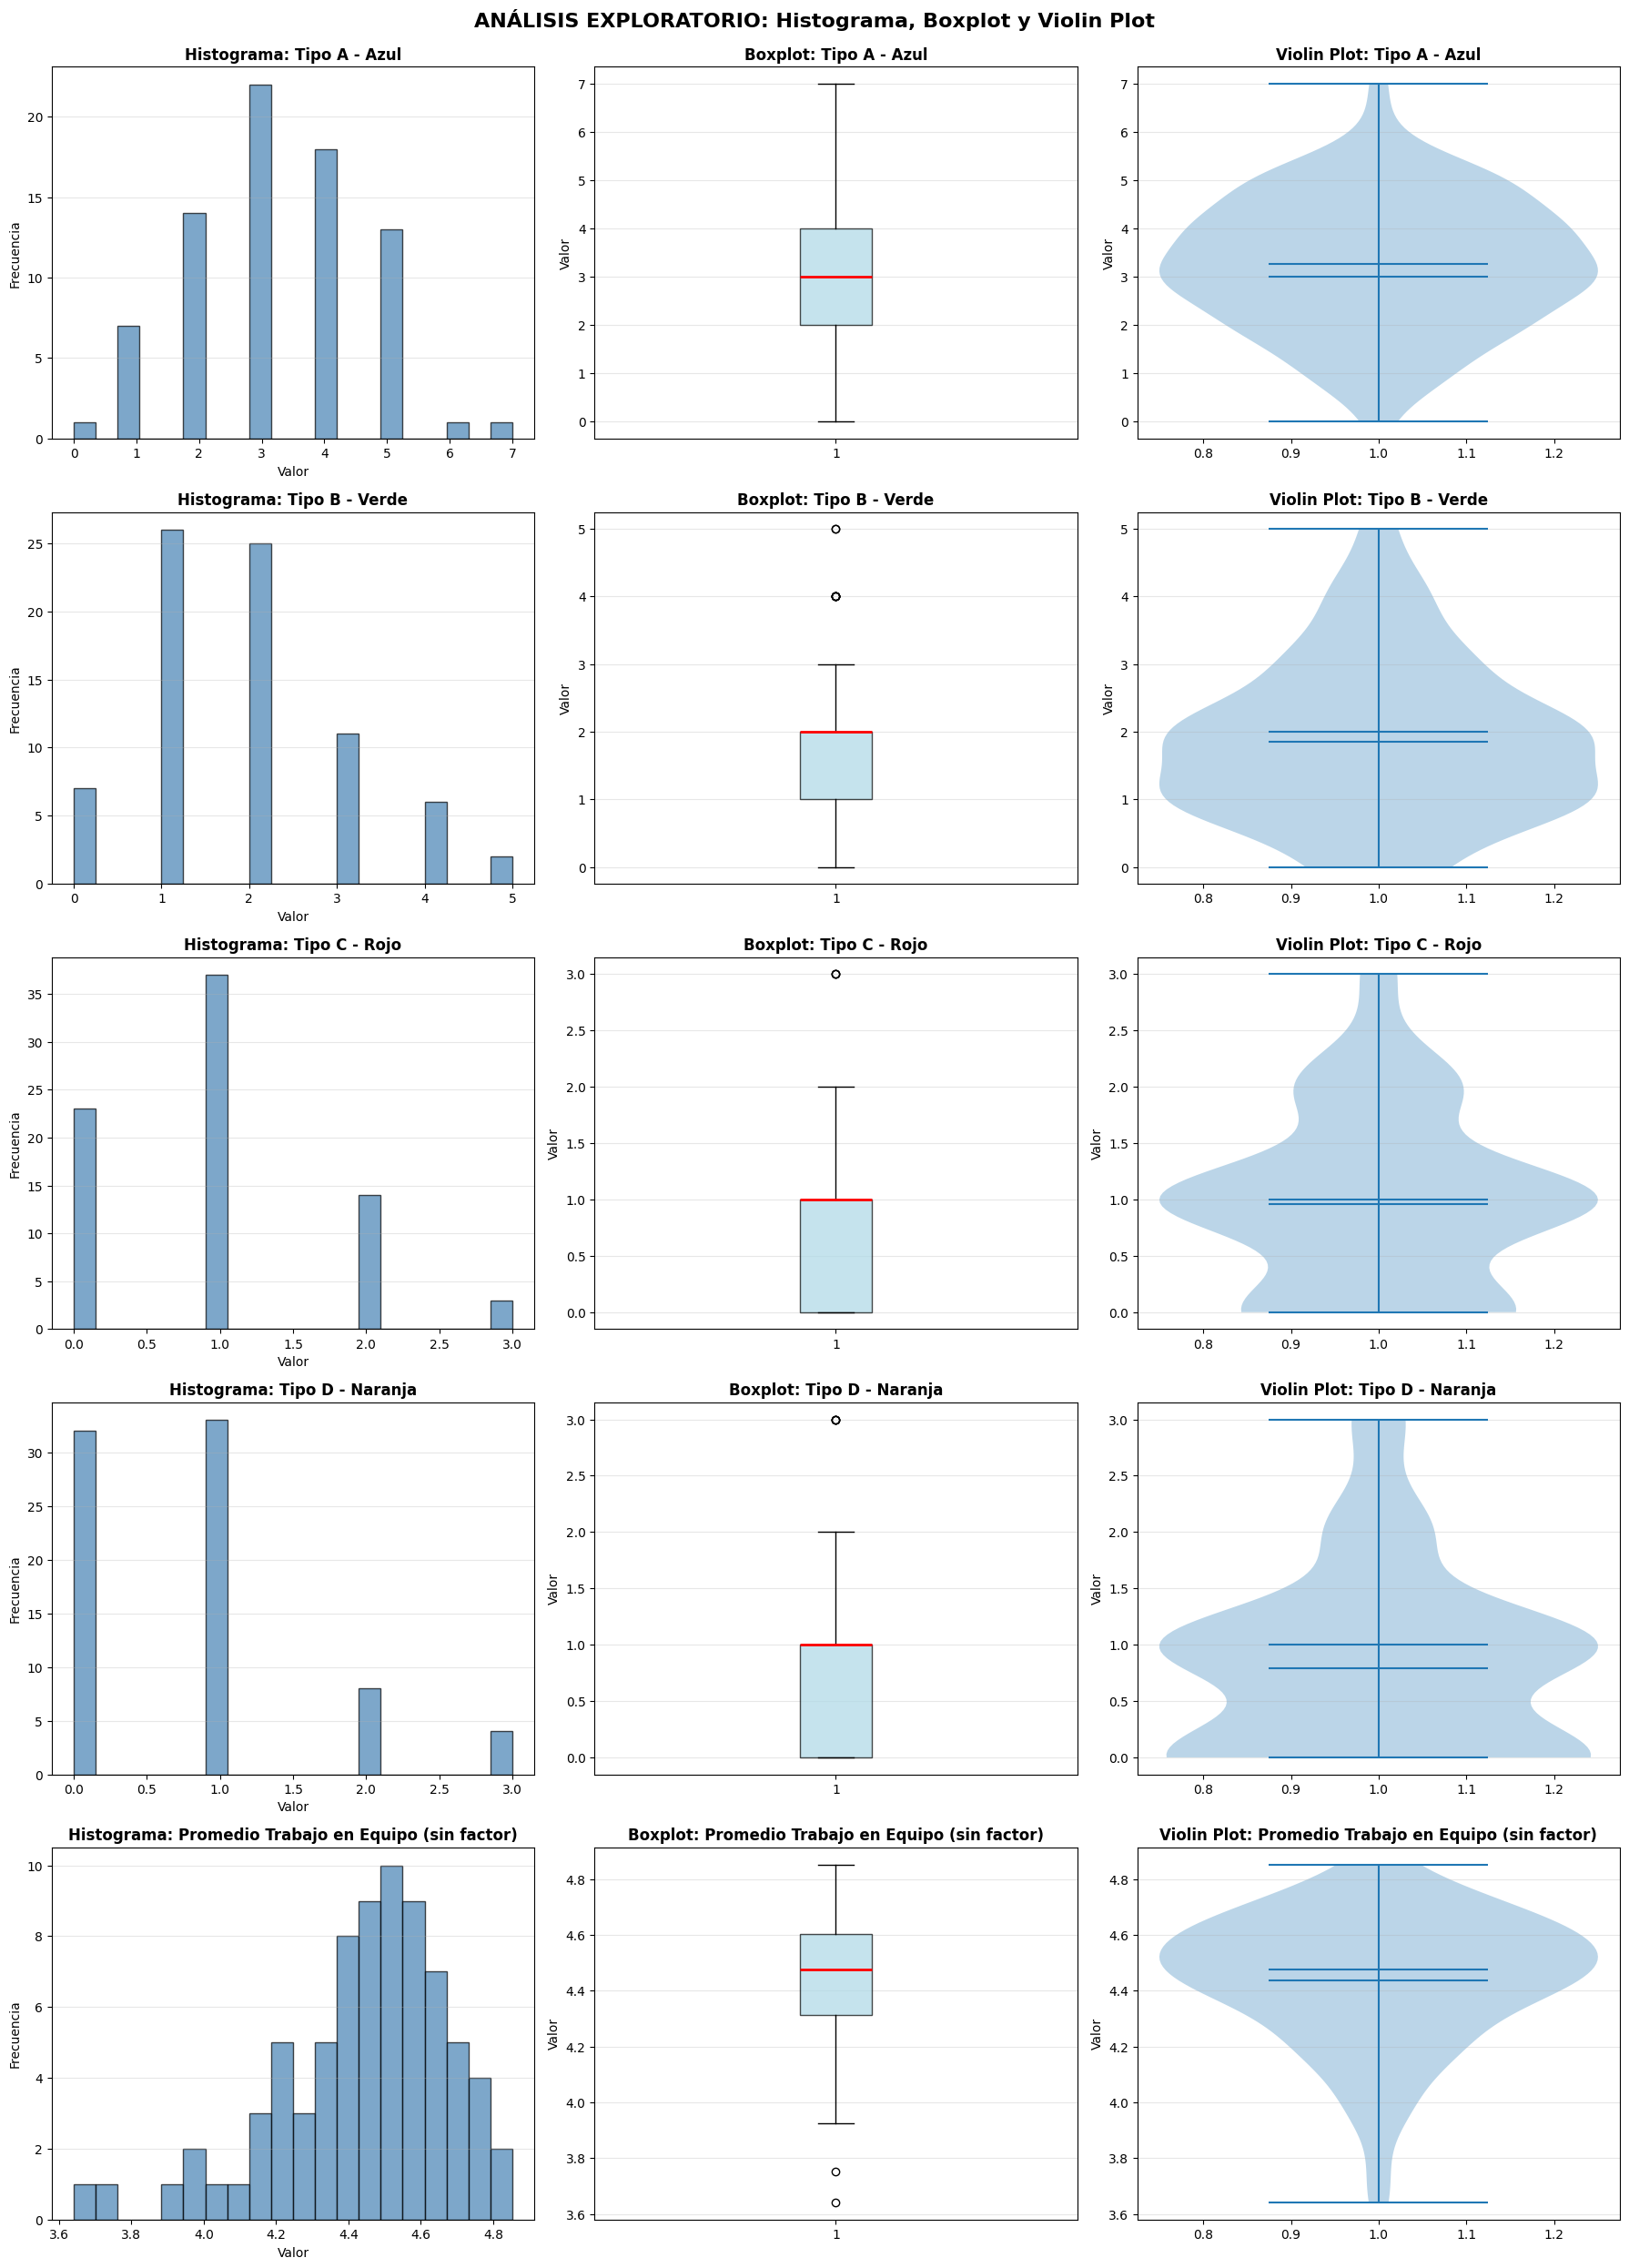

ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

       Tipo A - Azul  Tipo B - Verde  Tipo C - Rojo  Tipo D - Naranja  Promedio Trabajo en Equipo (sin factor)
count      77.000000       77.000000      77.000000         77.000000                                77.000000
mean        3.259740        1.857143       0.961039          0.792208                                 4.438601
std         1.361139        1.177802       0.801997          0.832524                                 0.238820
min         0.000000        0.000000       0.000000          0.000000                                 3.641067
25%         2.000000        1.000000       0.000000          0.000000                                 4.312054
50%         3.000000        2.000000       1.000000          1.000000                                 4.475767
75%         4.000000        2.000000       1.000000          1.000000                                 4.604179
max         7.000000        5.000000       3.000000          3

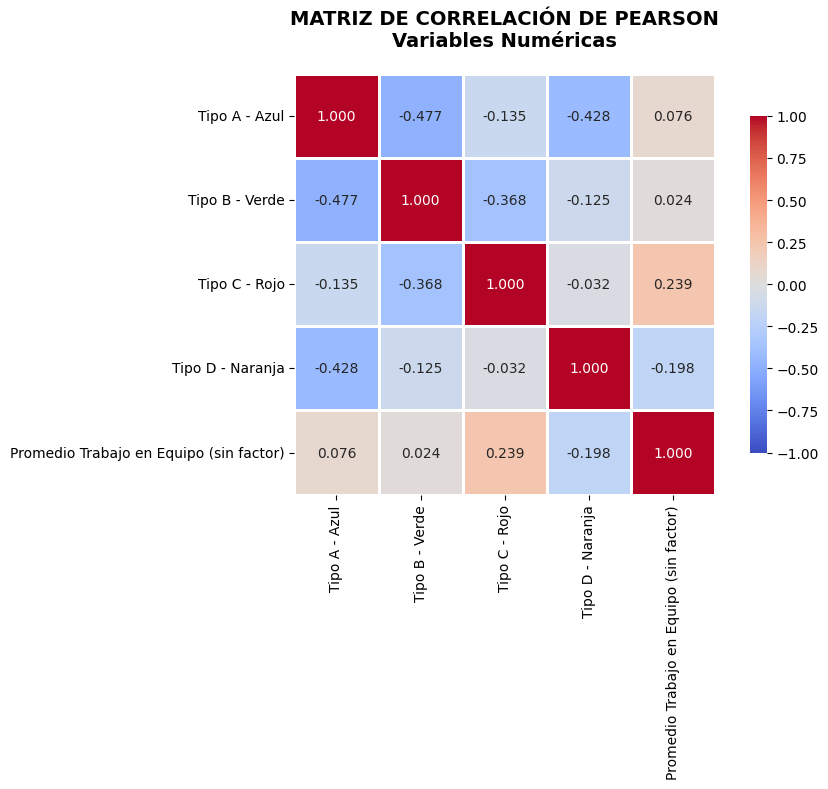

CORRELACIONES POR PARES - ANÁLISIS DETALLADO

      Variable 1                          Variable 2  Pearson r  Pearson p-value  Spearman r  Spearman p-value
   Tipo A - Azul                      Tipo B - Verde    -0.4772         0.000011     -0.4370          0.000071
   Tipo A - Azul                    Tipo D - Naranja    -0.4278         0.000104     -0.4410          0.000060
  Tipo B - Verde                       Tipo C - Rojo    -0.3681         0.000987     -0.3788          0.000680
   Tipo C - Rojo Promedio Trabajo en Equipo (sin fac     0.2394         0.035959      0.2424          0.033636
Tipo D - Naranja Promedio Trabajo en Equipo (sin fac    -0.1977         0.084734     -0.1133          0.326367
   Tipo A - Azul                       Tipo C - Rojo    -0.1352         0.240879     -0.1334          0.247545
  Tipo B - Verde                    Tipo D - Naranja    -0.1246         0.280263     -0.0983          0.394818
   Tipo A - Azul Promedio Trabajo en Equipo (sin fac     0.0757   

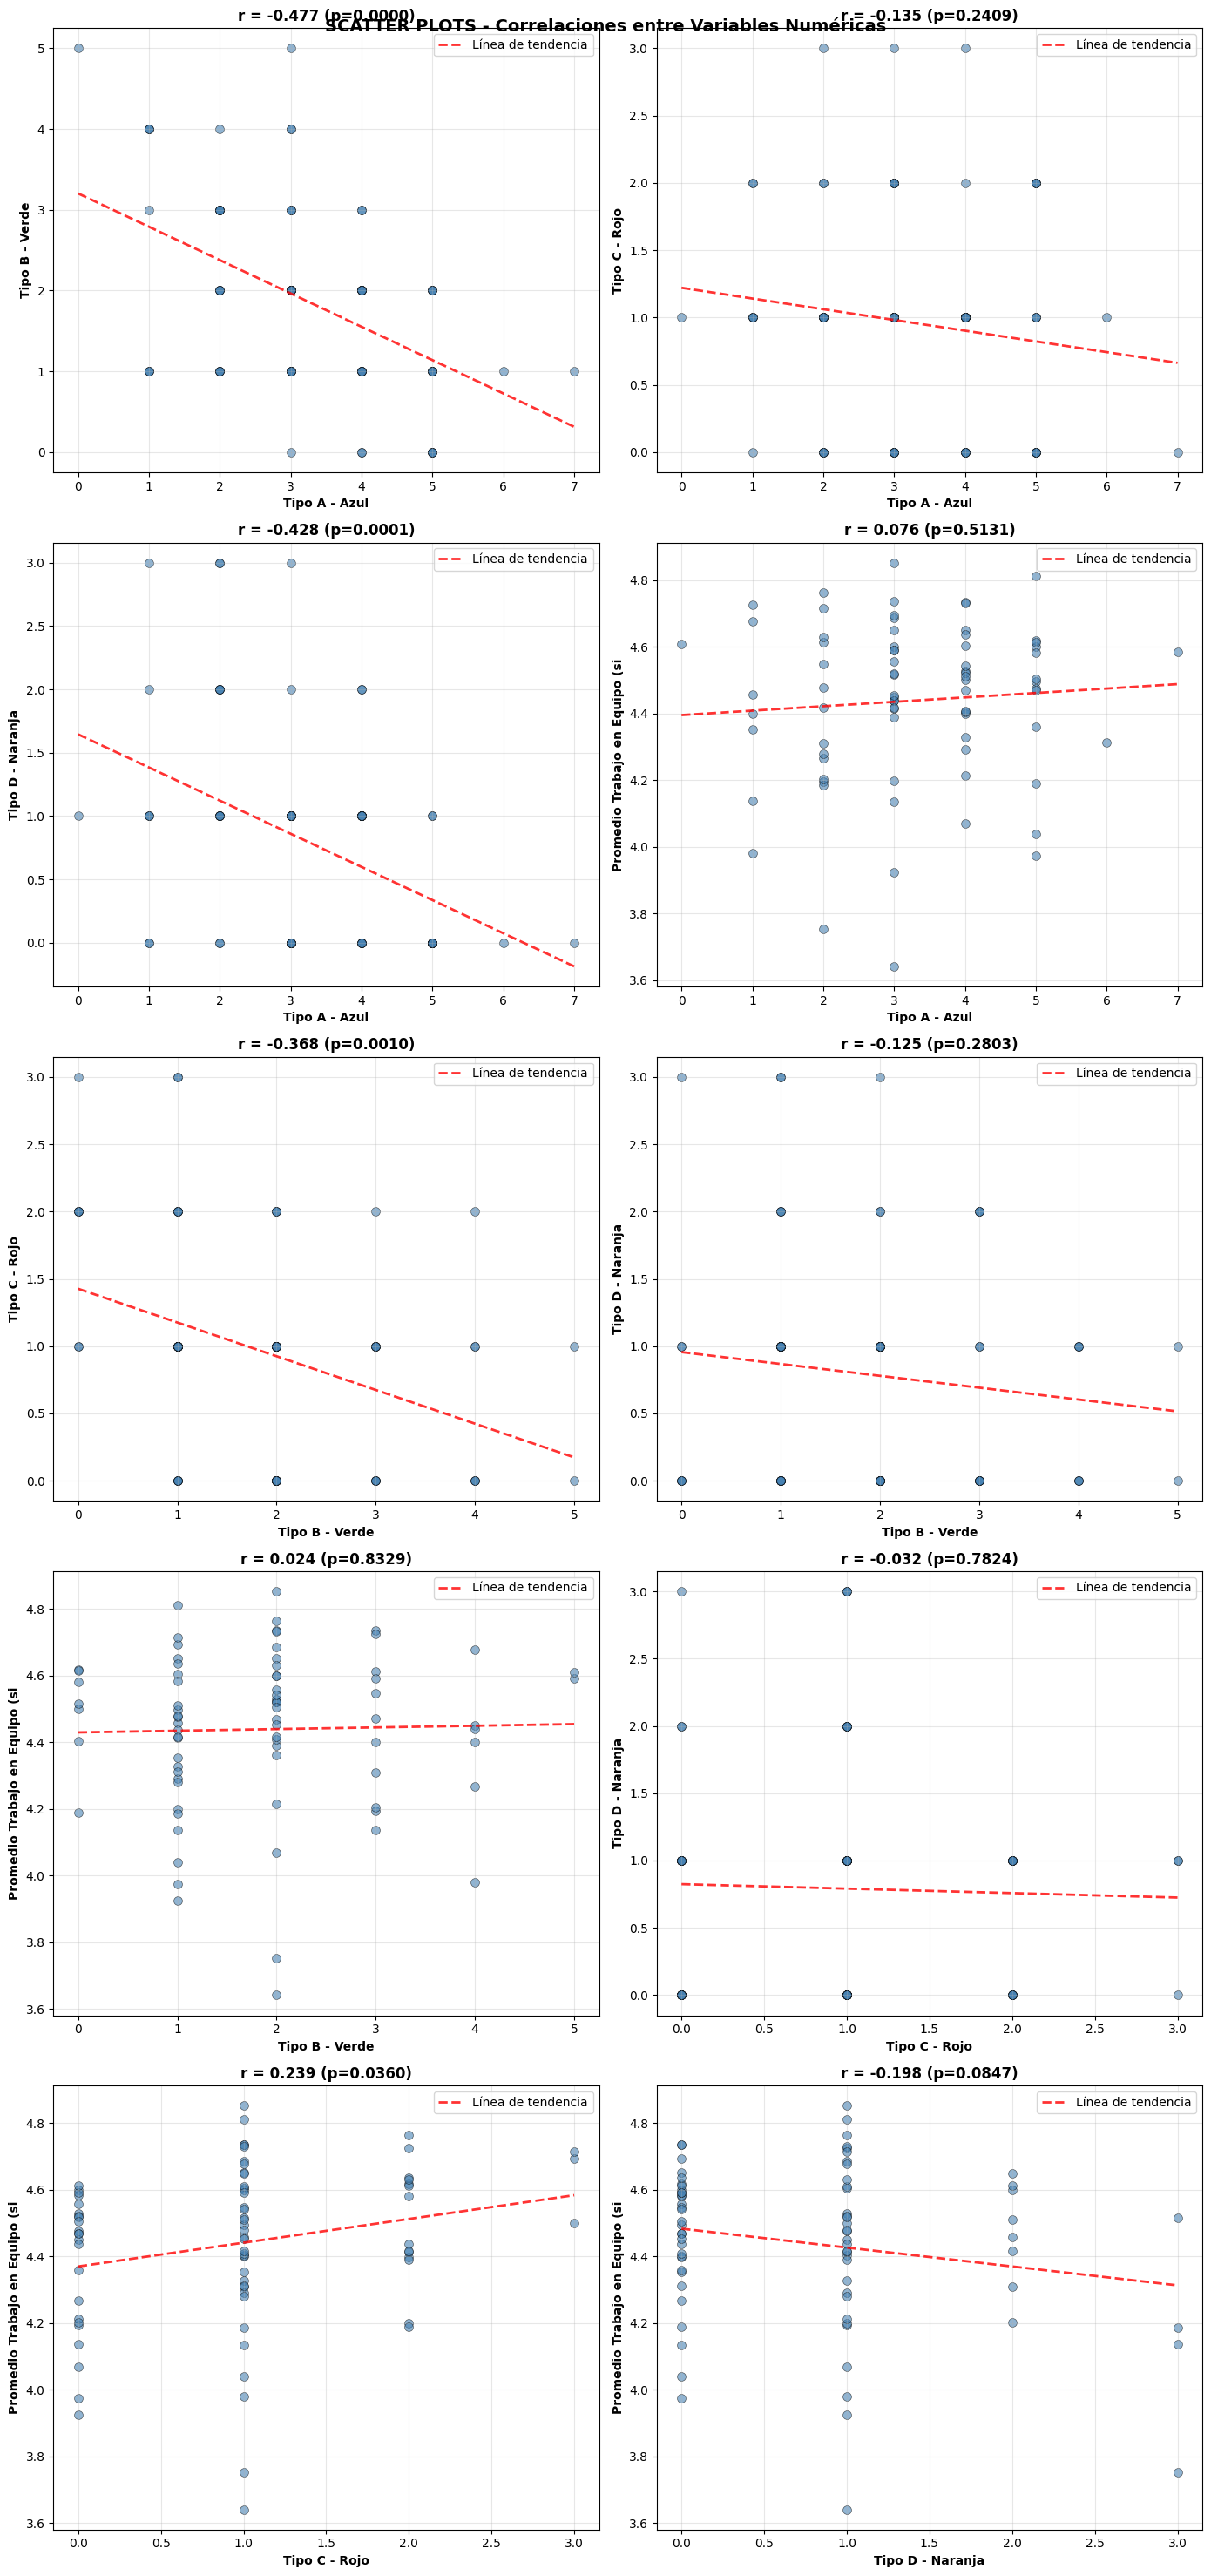

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>